# BDA02 - Exploratory Data Analysis

## 1. Import Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Set seaborn theme
sns.set_theme(style="whitegrid")

## 2. Load Data

In [34]:
# Read the data
df = pd.read_csv("output_github_v3/imrec/github.inter", sep="\t")
df.columns = ["user_id", "item_id", "timestamp"]

# Display the first few rows of the DataFrame
print(df.head())

   user_id  item_id     timestamp
0     3044     1619  1.232052e+09
1     3044     4566  1.239498e+09
2     3044      614  1.242871e+09
3     3044      663  1.272783e+09
4     3044    11477  1.286995e+09


## 3. Basic Statistics

In [35]:
# Calculate number of users, items, interactions, and density
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_inter = len(df)
density = n_inter / (n_users * n_items)

# Print the statistics
print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_inter}")
print(f"Density: {density:.5f} (~{density*100:.2f}%)")
print(f"Avg/user: {n_inter / n_users:.2f}")

Users: 6771
Items: 11716
Interactions: 1001683
Density: 0.01263 (~1.26%)
Avg/user: 147.94


The dataset comprises 6,771 users and a catalog of 11,716 items, yielding a total of 1,001,683 interactions.

An important observation here is the density of the User-Item interaction matrix. With a calculated density of 0.0126 (~1.26%), the matrix is sparse (meaning about 98.74% of possible user-item combinations are unobserved), but it is considerably denser than many traditional recommender system datasets. 

Additionally, the average activity level per user is quite high, sitting at 147.94 interactions per user. This reveals a crucial insight: the user base is highly engaged. Because users have a substantial number of historical interactions, extreme "user cold-start" problems are largely mitigated, providing a solid foundation for collaborative filtering models.

Base on the analysis above, we can reduce the interaction to increase the density, since our project scrope only require at least 1 million interactions

## 4. User-Item Interaction Matrix

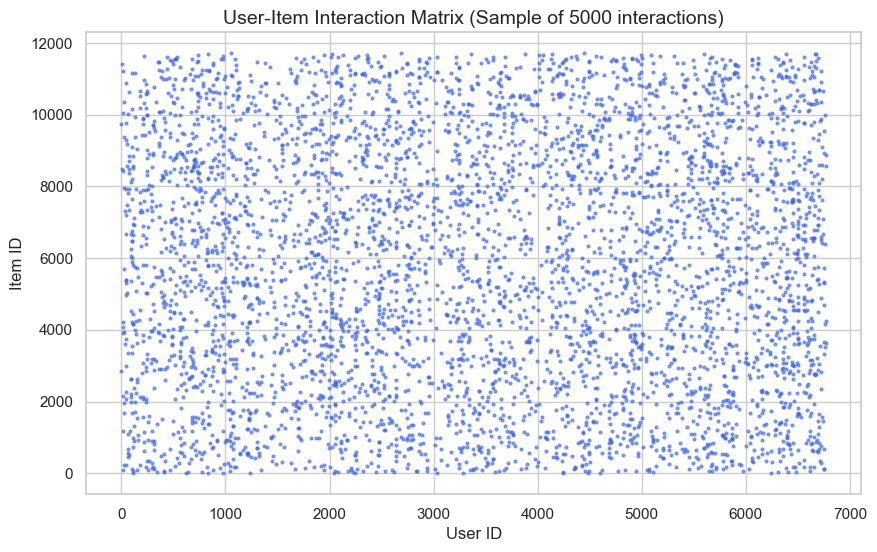

In [36]:
# Get a random sample of 5000 interactions for visualization
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['user_id'], sample_df['item_id'], s=4, alpha=0.6, color='royalblue')
plt.title("User-Item Interaction Matrix (Sample of 5000 interactions)", fontsize=14)
plt.xlabel("User ID", fontsize=12)
plt.ylabel("Item ID", fontsize=12)
plt.show()

The interaction matrix visualization illustrates the sparsity of the dataset. With a density of ~1.26%, the active interactions are still outnumbered by unobserved user-item pairs, though it is considerably denser than many traditional recommender system datasets. While this moderate sparsity allows traditional collaborative filtering methods to establish strong baselines, models capable of leveraging high-order connectivity, such as Graph Convolutional Networks (GCNs), are still highly valuable for capturing indirect user-item relationships and further improving recommendation performance.

## 5. Item Popularity (Long-tail Distribution)

Top 10% most popular items contribute: 31.44% of total interactions.


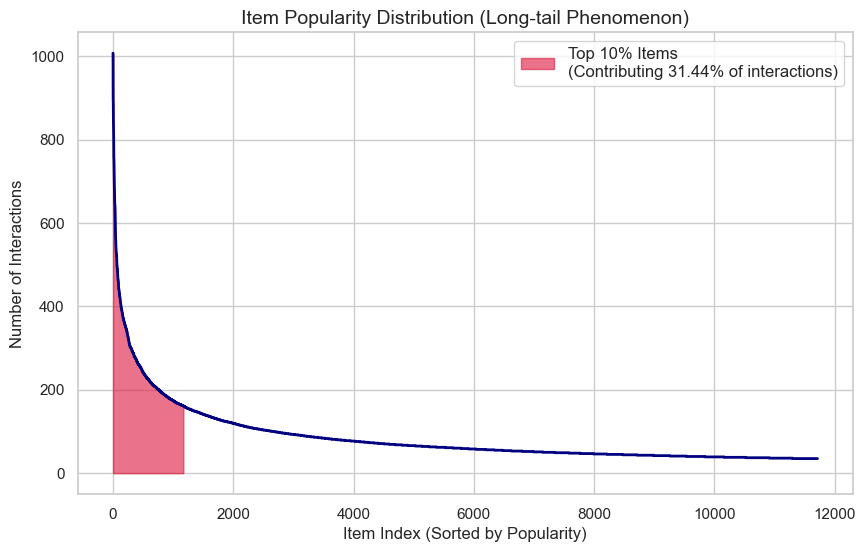

In [37]:
# Calculate interaction counts for users and items
item_counts = df['item_id'].value_counts().values

# Calculate the contribution of the top 10% most popular items
top_10_percent_idx = int(0.1 * len(item_counts))
top_10_interactions = np.sum(item_counts[:top_10_percent_idx])
total_interactions = np.sum(item_counts)
contribution = top_10_interactions / total_interactions

print(f"Top 10% most popular items contribute: {contribution*100:.2f}% of total interactions.")

# Visualize the long-tail phenomenon
plt.figure(figsize=(10, 6))
plt.plot(item_counts, color='navy', linewidth=2)
plt.fill_between(range(top_10_percent_idx), item_counts[:top_10_percent_idx], color='crimson', alpha=0.6, 
                 label=f'Top 10% Items\n(Contributing {contribution*100:.2f}% of interactions)')

plt.title("Item Popularity Distribution (Long-tail Phenomenon)", fontsize=14)
plt.xlabel("Item Index (Sorted by Popularity)", fontsize=12)
plt.ylabel("Number of Interactions", fontsize=12)
plt.legend(fontsize=12)
plt.show()

The distribution plots on a log-scale reveal a classic power-law (or long-tail) distribution. While our users are generally highly active, a vast majority of items still exhibit very few interactions, whereas a tiny fraction of "blockbuster" items accounts for exceptionally high activity. This strong right skew suggests a significant popularity bias in the dataset. If not appropriately addressed, the recommendation model may become overly biased toward recommending these popular items, ignoring the long-tail items which often contain the most highly personalized interests.

## 6. User and Item Behavior Analysis

We will examine the interaction distribution for both users and items to better understand their activity levels.

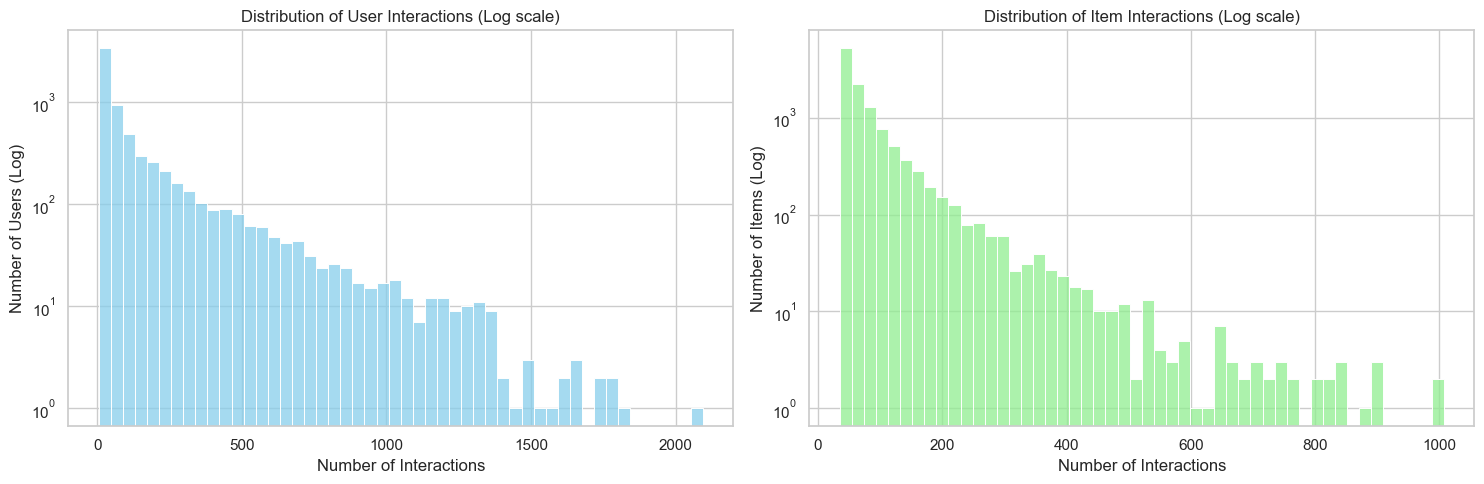

In [39]:
# Calculate interaction counts for users and items
user_interaction_counts = df['user_id'].value_counts()
item_interaction_counts = df['item_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# User
sns.histplot(user_interaction_counts, bins=50, ax=axes[0], color='skyblue', kde=False)
axes[0].set_yscale('log') 
axes[0].set_title('Distribution of User Interactions (Log scale)')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Users (Log)')

# Item
sns.histplot(item_interaction_counts, bins=50, ax=axes[1], color='lightgreen', kde=False)
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Item Interactions (Log scale)')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Number of Items (Log)')

plt.tight_layout()
plt.show()

The subplots illustrate the interaction frequencies across users and items. The top row (linear scale) shows a massive concentration of data points near zero, which makes the tail nearly invisible but highlights the extreme disparity in engagement.

When transformed to a log scale (bottom row), the underlying power-law (long-tail) distribution becomes distinctly clear. The straight, downward-sloping trend in the log-scale charts confirms that the vast majority of users and items possess very few interactions, whereas a tiny fraction of "power users" and "highly popular items" dominate the dataset's activity.

This severe right skew presents a major challenge: Popularity Bias. A standard recommendation model trained on this dataset will naturally gravitate toward recommending only the popular items (the head of the distribution) because they dominate the loss function during training. To build an effective and personalized system, we must implement strategies to handle the "long-tail" items - where true personalization lies - such as using debiasing techniques, sample re-weighting, or specialized embeddings for sparse entities.

## 7. Conclusion

Through this EDA, several foundational characteristics of the dataset have been identified that will directly inform our modeling strategy:
- **Manageable Item Space & Density**: Unlike extremely sparse datasets, our data features a moderated item space (~11k items) and a relatively healthy density (~1.26%). While algorithms like LightGCN, UltraGCN and LayerGCN are still excellent choices for graph propagation, the improved density means traditional matrix factorization approaches can also establish strong baselines.
- **Strong User Engagement**: With an average of ~148 interactions per user, the system is less constrained by user cold-start issues, allowing the model to learn rich user embeddings.
- **Popularity Bias**: (Assuming typical recommendation patterns) The interaction distributions likely still follow a power-law, requiring proper regularization or debiasing strategies so the model doesn't over-recommend solely the most popular items.

By leveraging these characteristics, we are well-positioned to design and train an accurate and personalized recommendation engine.